<a href="https://colab.research.google.com/github/AhmadObaidat/School/blob/main/CREDIT_CARD_FRAUD_MODEL_Full_end_to_end_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# WEEK 6 - CREDIT CARD FRAUD MODEL FINALIZATION
# Full end-to-end pipeline for Google Colab
# ============================================

import urllib.request
import pathlib
import os
import time

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    make_scorer
)

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression


# -----------------------------
# 1) DOWNLOAD & LOAD THE DATA
# -----------------------------
start_time = time.time()

data_url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
data_path = pathlib.Path("creditcard.csv")

if not data_path.exists():
    print("Downloading creditcard.csv dataset...")
    urllib.request.urlretrieve(data_url, data_path)
    print("Download complete.")
else:
    print("creditcard.csv already exists, skipping download.")

print("\nLoading dataset...")
df = pd.read_csv(data_path)
print("Dataset loaded.")
print("Shape:", df.shape)
print(df.head())


# ------------------------------------------
# 2) PREPROCESSING: LOG + STANDARDIZATION
# ------------------------------------------
print("\nPreprocessing...")

# Separate features and target
X = df.drop("Class", axis=1).copy()
y = df["Class"].copy()

# Log-transform Amount to reduce skew
X["Amount_log"] = np.log1p(X["Amount"])
X = X.drop("Amount", axis=1)

# Stratified train-test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Standardize numeric features (fit on train only)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class distribution:\n", y_train.value_counts())
print("Test class distribution:\n", y_test.value_counts())


# -----------------------------------
# 3) CV & SCORING SETUP (F1 FRAUD)
# -----------------------------------
print("\nSetting up CV and scoring...")

f1_fraud_scorer = make_scorer(f1_score, pos_label=1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# -----------------------------------
# 4) HELPER: GRID SEARCH WRAPPER
# -----------------------------------
def run_grid_search(model, param_grid, model_name):
    """
    Runs GridSearchCV on the given model and param_grid,
    optimizing F1-score for fraud class (1).
    """
    print(f"\n=== TUNING {model_name} ===")
    grid = GridSearchCV(
        model,
        param_grid,
        scoring=f1_fraud_scorer,
        cv=cv,
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X_train, y_train)
    print(f"Best params for {model_name}: {grid.best_params_}")
    print(f"Best CV F1 (fraud=1) for {model_name}: {grid.best_score_:.4f}")
    return grid.best_estimator_, grid


# -----------------------------------
# 5) TUNE MODELS (FAST, OPTIMIZED)
# -----------------------------------

# kNN (FAST GRID)
knn = KNeighborsClassifier()
param_grid_knn = {
    "n_neighbors": [3, 5, 7],
    "weights": ["uniform", "distance"]
}
best_knn, grid_knn = run_grid_search(knn, param_grid_knn, "kNN")


# Random Forest (FAST GRID)
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
param_grid_rf = {
    "n_estimators": [200],          # single solid value
    "max_depth": [None, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "class_weight": ["balanced"]
}
best_rf, grid_rf = run_grid_search(rf, param_grid_rf, "Random Forest")


# MLP (FAST GRID)
mlp = MLPClassifier(max_iter=300, random_state=42)
param_grid_mlp = {
    "hidden_layer_sizes": [(50,), (100,)],
    "alpha": [0.0001, 0.001]
}
best_mlp, grid_mlp = run_grid_search(mlp, param_grid_mlp, "MLP")


# AdaBoost (BOOSTING)
ada = AdaBoostClassifier(random_state=42)
param_grid_ada = {
    "n_estimators": [50, 100],
    "learning_rate": [0.1, 1.0]
}
best_ada, grid_ada = run_grid_search(ada, param_grid_ada, "AdaBoost")


# -----------------------------------
# 6) BUILD STACKING ENSEMBLE
# -----------------------------------
print("\nBuilding stacking ensemble...")

estimators = [
    ("rf", best_rf),
    ("knn", best_knn),
    ("mlp", best_mlp)
]

final_estimator = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    n_jobs=-1,
    passthrough=False
)

stacking_clf.fit(X_train, y_train)
print("Stacking ensemble fitted.")


# -----------------------------------
# 7) EVALUATION HELPER
# -----------------------------------
def evaluate_model(name, model, X_test, y_test):
    """
    Evaluates model on test set and returns metrics,
    focusing on fraud class (1).
    """
    y_pred = model.predict(X_test)

    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)

    # Some models may not have predict_proba
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = None

    print(f"\n=== {name} ===")
    print(f"Precision (fraud=1): {precision:.4f}")
    print(f"Recall    (fraud=1): {recall:.4f}")
    print(f"F1-score  (fraud=1): {f1:.4f}")
    if auc is not None:
        print(f"ROC-AUC:            {auc:.4f}")
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification report:\n", classification_report(y_test, y_pred, digits=4))
    print("-" * 70)

    return {
        "model": name,
        "precision_fraud": precision,
        "recall_fraud": recall,
        "f1_fraud": f1,
        "roc_auc": auc
    }


# -----------------------------------
# 8) EVALUATE ALL MODELS ON TEST SET
# -----------------------------------
print("\nEvaluating tuned models and ensemble on test set...")

models = {
    "kNN_tuned": best_knn,
    "RandomForest_tuned": best_rf,
    "MLP_tuned": best_mlp,
    "AdaBoost_tuned": best_ada,
    "Stacking": stacking_clf
}

results = []
for name, model in models.items():
    res = evaluate_model(name, model, X_test, y_test)
    results.append(res)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="f1_fraud", ascending=False).reset_index(drop=True)

print("\n======================")
print("SUMMARY OF MODELS (SORTED BY F1-SCORE FOR FRAUD)")
print("======================")
print(results_df)

elapsed = time.time() - start_time
print(f"\nTotal runtime: {elapsed/60:.2f} minutes")


Download complete.

Loading dataset...
Dataset loaded.
Shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns  # usually preinstalled in Colab
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay,
    classification_report,
)
import pandas as pd


In [ ]:
# 1) Collect your final models here
models = {
    "kNN_tuned": best_knn,
    "RandomForest_tuned": best_rf,
    "MLP_tuned": best_mlp,
    "AdaBoost_tuned": best_ada,
    "Stacking": stacking_clf,
}

# 2) Compute metrics for each model
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = None

    results.append({
        "model": name,
        "precision_fraud": precision,
        "recall_fraud": recall,
        "f1_fraud": f1,
        "roc_auc": auc,
    })

results_df = pd.DataFrame(results).sort_values(
    by="f1_fraud", ascending=False
).reset_index(drop=True)

results_df


NameError: name 'best_knn' is not defined

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["model"], results_df["f1_fraud"])
plt.title("Fraud Class F1-Score by Model")
plt.xlabel("Model")
plt.ylabel("F1-Score (Fraud = 1)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


NameError: name 'results_df' is not defined

<Figure size 800x500 with 0 Axes>

In [ ]:
whos


Variable                Type        Data/Info
---------------------------------------------
RocCurveDisplay         type        <class 'sklearn.metrics._<...>c_curve.RocCurveDisplay'>
classification_report   function    <function classification_<...>report at 0x7cd232707880>
confusion_matrix        function    <function confusion_matrix at 0x7cd232706520>
f1_score                function    <function f1_score at 0x7cd232706ca0>
pd                      module      <module 'pandas' from '/u<...>ages/pandas/__init__.py'>
plt                     module      <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
precision_score         function    <function precision_score at 0x7cd2327074c0>
recall_score            function    <function recall_score at 0x7cd232707600>
roc_auc_score           function    <function roc_auc_score at 0x7cd2327f5c60>
sns                     module      <module 'seaborn' from '/<...>ges/seaborn/__init__.py'>


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

# --- recreate best models using the hyperparameters you found earlier ---

# kNN tuned
best_knn = KNeighborsClassifier(
    n_neighbors=3,
    weights="uniform"
)

# Random Forest tuned
best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# MLP tuned
best_mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    alpha=0.0001,
    max_iter=300,
    random_state=42
)

# AdaBoost tuned
best_ada = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

# Stacking ensemble
estimators = [
    ("rf", best_rf),
    ("knn", best_knn),
    ("mlp", best_mlp),
]

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42,
    ),
    n_jobs=-1
)

# Fit all models (needed before evaluation)
best_knn.fit(X_train, y_train)
best_rf.fit(X_train, y_train)
best_mlp.fit(X_train, y_train)
best_ada.fit(X_train, y_train)
stacking_clf.fit(X_train, y_train)

print("All models recreated and fitted successfully.")


NameError: name 'X_train' is not defined

Download complete.
Dataset loaded. Shape: (284807, 31)
Train shape: (227845, 30)  Test shape: (56962, 30)
Train class distribution:
 Class
0    227451
1       394
Name: count, dtype: int64
Test class distribution:
 Class
0    56864
1       98
Name: count, dtype: int64

Fitting models (no tuning, just final configs)...
All models fitted.

=== kNN_tuned ===
Precision (fraud=1): 0.9205
Recall    (fraud=1): 0.8265
F1-score  (fraud=1): 0.8710
ROC-AUC:            0.9336
Confusion matrix:
 [[56857     7]
 [   17    81]]

Classification report:
               precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998     56864
           1     0.9205    0.8265    0.8710        98

    accuracy                         0.9996     56962
   macro avg     0.9601    0.9132    0.9354     56962
weighted avg     0.9996    0.9996    0.9996     56962

----------------------------------------------------------------------

=== RandomForest_tuned ===
Precision (fraud=1): 0.9487
Re

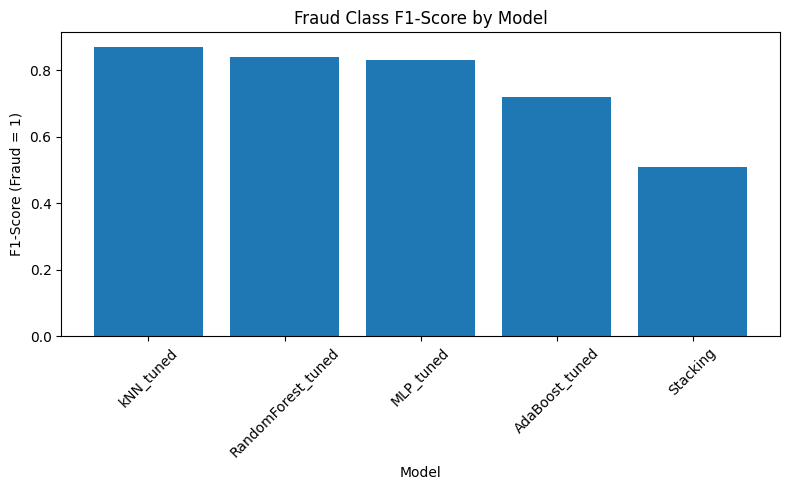

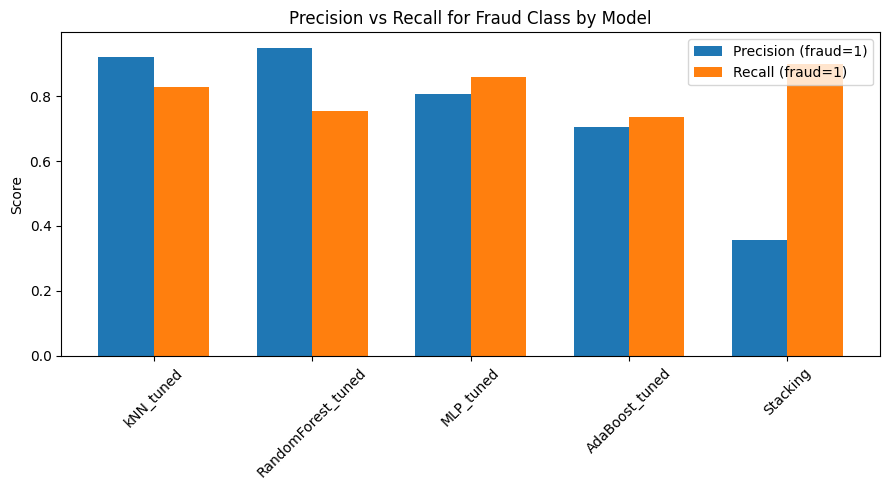

<Figure size 800x600 with 0 Axes>

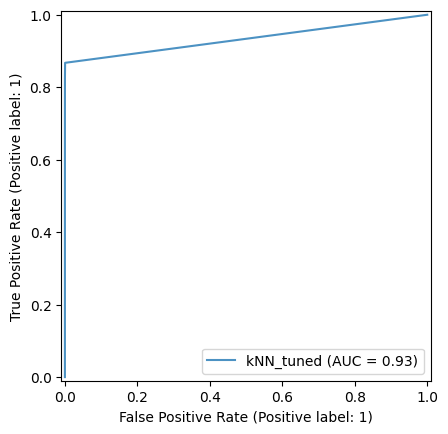

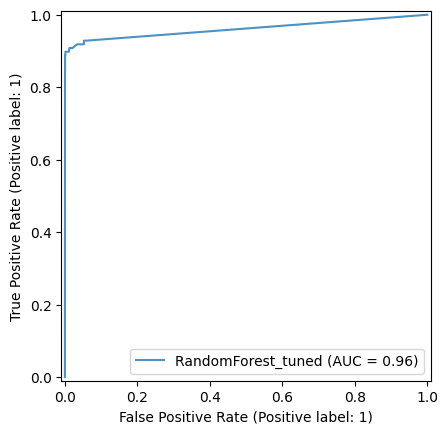

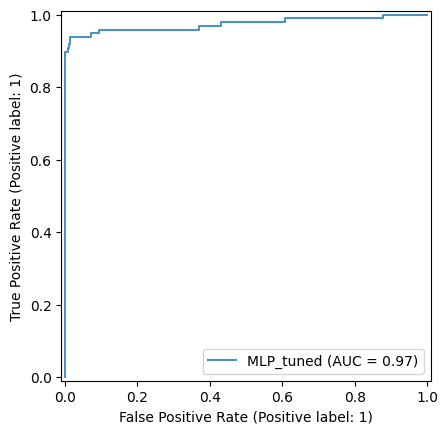

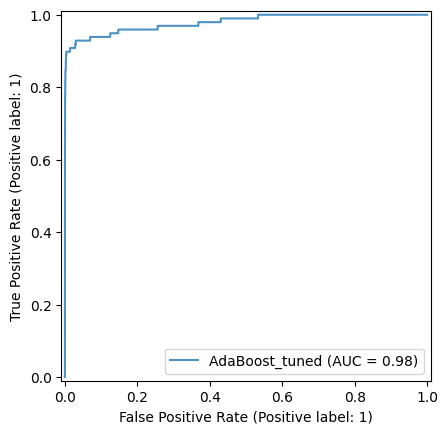

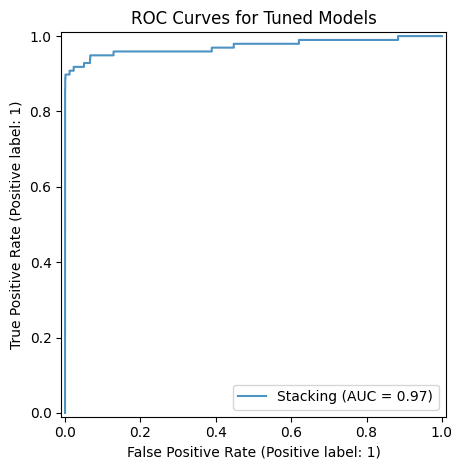

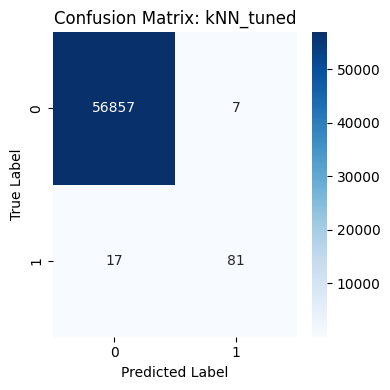

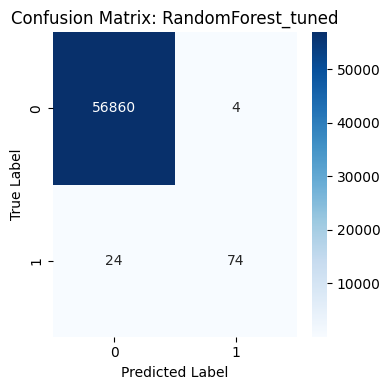

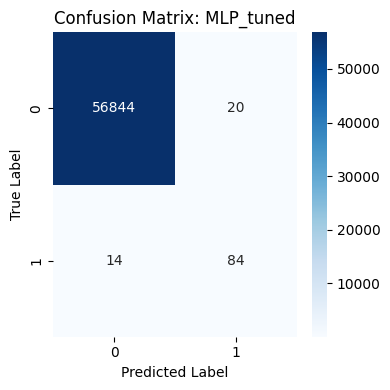

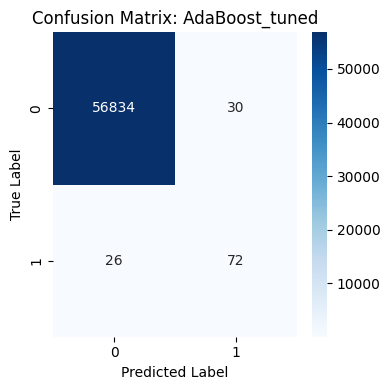

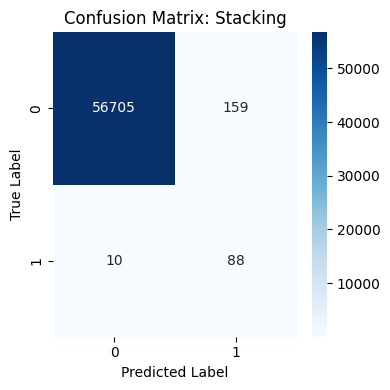


Total runtime (this cell): 13.10 minutes


In [ ]:
# ============================================
# REBUILD MODELS + VISUALIZE RESULTS (WEEK 6)
# ============================================

import urllib.request
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

start_time = time.time()

# -----------------------------
# 1) LOAD DATASET (FAST)
# -----------------------------
data_url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
data_path = pathlib.Path("creditcard.csv")

if not data_path.exists():
    print("Downloading creditcard.csv dataset...")
    urllib.request.urlretrieve(data_url, data_path)
    print("Download complete.")
else:
    print("creditcard.csv already exists, using local copy.")

df = pd.read_csv(data_path)
print("Dataset loaded. Shape:", df.shape)

# -----------------------------
# 2) PREPROCESSING
# -----------------------------
X = df.drop("Class", axis=1).copy()
y = df["Class"].copy()

# Log-transform Amount
X["Amount_log"] = np.log1p(X["Amount"])
X = X.drop("Amount", axis=1)

# Stratified 80/20 split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class distribution:\n", y_train.value_counts())
print("Test class distribution:\n", y_test.value_counts())

# -----------------------------
# 3) RECREATE TUNED MODELS
#    (Using best params from your GridSearch)
# -----------------------------
best_knn = KNeighborsClassifier(
    n_neighbors=3,
    weights="uniform"
)

best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

best_mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    alpha=0.0001,
    max_iter=300,
    random_state=42
)

best_ada = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

estimators = [
    ("rf", best_rf),
    ("knn", best_knn),
    ("mlp", best_mlp),
]

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),
    n_jobs=-1
)

# Fit all models
print("\nFitting models (no tuning, just final configs)...")
best_knn.fit(X_train, y_train)
best_rf.fit(X_train, y_train)
best_mlp.fit(X_train, y_train)
best_ada.fit(X_train, y_train)
stacking_clf.fit(X_train, y_train)
print("All models fitted.")

# -----------------------------
# 4) EVALUATION + RESULTS TABLE
# -----------------------------
models = {
    "kNN_tuned": best_knn,
    "RandomForest_tuned": best_rf,
    "MLP_tuned": best_mlp,
    "AdaBoost_tuned": best_ada,
    "Stacking": stacking_clf
}

results = []

def eval_and_print(name, model):
    y_pred = model.predict(X_test)

    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = None

    print(f"\n=== {name} ===")
    print(f"Precision (fraud=1): {precision:.4f}")
    print(f"Recall    (fraud=1): {recall:.4f}")
    print(f"F1-score  (fraud=1): {f1:.4f}")
    if auc is not None:
        print(f"ROC-AUC:            {auc:.4f}")
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification report:\n", classification_report(y_test, y_pred, digits=4))
    print("-" * 70)

    return {
        "model": name,
        "precision_fraud": precision,
        "recall_fraud": recall,
        "f1_fraud": f1,
        "roc_auc": auc
    }

for name, model in models.items():
    res = eval_and_print(name, model)
    results.append(res)

results_df = pd.DataFrame(results).sort_values(
    by="f1_fraud", ascending=False
).reset_index(drop=True)

print("\nSUMMARY TABLE (sorted by F1-score for fraud class):")
print(results_df)

# -----------------------------
# 5) VISUALIZATIONS
# -----------------------------

# A) F1-score bar chart
plt.figure(figsize=(8, 5))
plt.bar(results_df["model"], results_df["f1_fraud"])
plt.title("Fraud Class F1-Score by Model")
plt.xlabel("Model")
plt.ylabel("F1-Score (Fraud = 1)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# B) Precision vs Recall per model
x = np.arange(len(results_df))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, results_df["precision_fraud"], width, label="Precision (fraud=1)")
plt.bar(x + width/2, results_df["recall_fraud"], width, label="Recall (fraud=1)")
plt.xticks(x, results_df["model"], rotation=45)
plt.ylabel("Score")
plt.title("Precision vs Recall for Fraud Class by Model")
plt.legend()
plt.tight_layout()
plt.show()

# C) ROC curves for all models with predict_proba
plt.figure(figsize=(8, 6))
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, alpha=0.8)
plt.title("ROC Curves for Tuned Models")
plt.tight_layout()
plt.show()

# D) Confusion matrix heatmap for each model
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

elapsed = time.time() - start_time
print(f"\nTotal runtime (this cell): {elapsed/60:.2f} minutes")ee. Terms Apply. Learn more at gemini.google/students and colab.research.google.com/signup 🎓
Learn more
Twk6_model_tuning.ipynb
Twk6_model_tuning.ipynb_




In [ ]:
importances = best_rf.feature_importances_
